In [1]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [2]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [3]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [4]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [5]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [6]:
import matplotlib.pyplot as plt

In [7]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

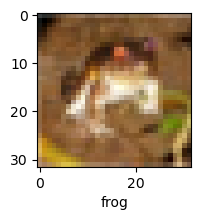

In [8]:
plot_sample(x_train, y_train, 0)

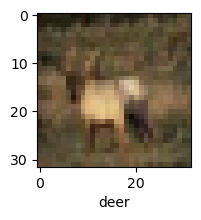

In [9]:
plot_sample(x_train, y_train, 3)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models 
import matplotlib.pyplot as plt
import numpy as np

In [11]:
x_train[1]

array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]

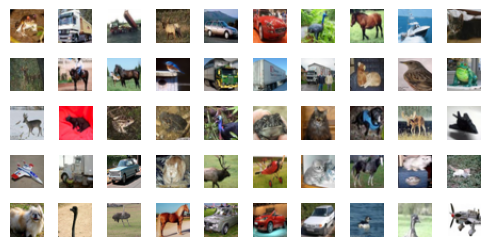

In [12]:
plt.figure(figsize=(5,5))

for i in range(50):
    plt.subplot(10, 10, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Scaling

In [13]:
x_train = x_train / 255
x_test = x_test / 255

In [14]:
x_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [15]:
model = models.Sequential([
    
    #CNN
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    #dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')

])

D:\conda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 40ms/step - accuracy: 0.4867 - loss: 1.4312
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6309 - loss: 1.0616
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 42ms/step - accuracy: 0.6784 - loss: 0.9212
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.7136 - loss: 0.8225
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7399 - loss: 0.7418
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - accuracy: 0.7655 - loss: 0.6692
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7888 - loss: 0.6048
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8107 - loss: 0.5398
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.8274 - loss: 0.4884
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8501 - loss: 0.4291


In [19]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6982 - loss: 1.0165


[1.0165358781814575, 0.698199987411499]

In [20]:
y_test = y_test.reshape(-1,)

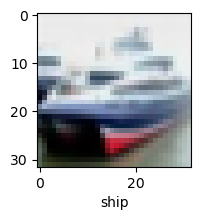

In [21]:
plot_sample(x_test, y_test, 1)

In [23]:
y_pred = model.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


array([[3.5400112e-04, 1.8709298e-03, 5.2723126e-04, 9.5510471e-01,
        2.4801549e-05, 4.0623900e-02, 8.4557403e-05, 1.8821596e-04,
        1.1450686e-03, 7.6693308e-05],
       [6.1750237e-04, 4.2226756e-01, 2.5894886e-08, 5.4134756e-07,
        1.6104293e-10, 2.4160565e-10, 9.1203450e-10, 6.4680522e-12,
        5.7696933e-01, 1.4501948e-04],
       [2.1384151e-01, 7.9350442e-02, 1.8297553e-03, 2.1480266e-03,
        3.0357158e-03, 3.3900189e-05, 5.2755189e-07, 1.0630061e-03,
        6.8604207e-01, 1.2655139e-02],
       [9.9829882e-01, 7.5345091e-04, 1.6183378e-05, 4.2153562e-05,
        4.8235388e-06, 9.4154007e-07, 6.9309664e-08, 1.1981075e-07,
        8.8291994e-04, 4.1828986e-07],
       [3.5347023e-07, 1.0703274e-04, 1.8794822e-02, 2.0456511e-01,
        2.0788199e-01, 4.5627276e-03, 5.6407571e-01, 4.8320812e-06,
        5.9515087e-06, 1.4607294e-06]], dtype=float32)

In [24]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

In [25]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

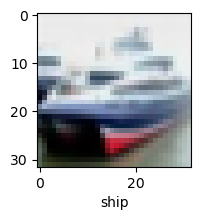

In [26]:
plot_sample(x_test, y_test, 1)

In [27]:
classes[y_classes[1]]

'ship'